In [99]:
# Importar dataset
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, roc_auc_score
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    precision_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)




df = pd.read_csv("../data/creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [49]:
# Verificamos el tamaño del dataset y si hay columnas con valores nulos

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

**Observaciones**

Podemos ver que el dataset contiene 31 columnas con 284,807 registros. De los cuales no hay valores nulos. Todas las columnas son de tipo float excepto, la columna *class* que es la columna objetivo y que clasifica si la operación es o no, fraude. 

Por lo que no hay que hacer cambio de tipo de dato. 

In [50]:
# Verificaremos cómo está la distribución de los datos con la función describe

df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


**Observaciones**
Podenmos observar que las variables *V1 a V28*, están demasiado separados. Si nos fijamos en el valor mínimo vs el percentil 50, que coincide con la mediana de los datos, vs el valos máximo, vemos que hay mucha diferencia.

Por otro lado, la columna *Amount*, pasa lo mismo. La desviación estandar es de 250, mediana 22, un promedio de 88  y el valor máximo 25,691. 

Por lo que los montos de las transacciones muestran una distribución muy sesgada a la derecha. Si bien la transacción promedio es de $88, la mediana es de solo $22, lo que indica que la mayoría de las transacciones son relativamente pequeñas. Unas pocas transacciones de alto valor (hasta $25,691) aumentan significativamente la media y la desviación estándar. Este patrón es típico en los sistemas de pago y sugiere la presencia de valores atípicos que podrían ser relevantes para los modelos de detección de fraude.



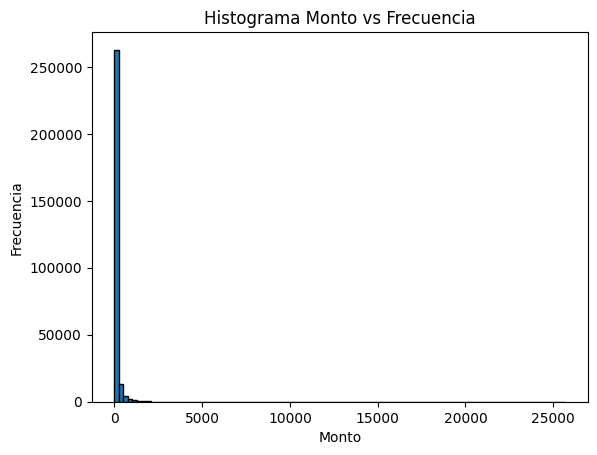

In [54]:
# Veamos la frecuencia del Monto en el dataset

plt.hist(df['Amount'], bins=100, edgecolor='black')
plt.title('Histograma Monto vs Frecuencia')
plt.xlabel('Monto')
plt.ylabel('Frecuencia')
plt.show()

Text(0.5, 1.0, 'Boxplot de Fraude vs Monto')

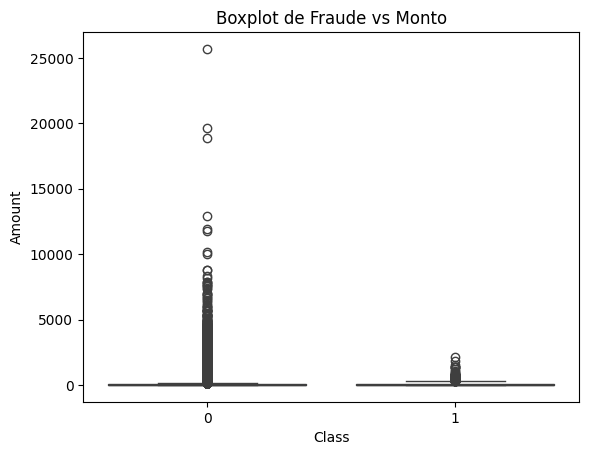

In [55]:
# Gráfica de Fraude vs Monto

sns.boxplot(x='Class', y='Amount', data=df)
plt.title('Boxplot de Fraude vs Monto')

In [71]:
df['Amount_log'] = np.log1p(df['Amount'])
df['Amount_scaled'] = StandardScaler().fit_transform(df[['Amount_log']])

In [56]:
# Veamos cómo es la distribución de los datos de acuerdo a las clases si es o no, fraude
df['Class'].value_counts(normalize=True)

Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64

**Observaciones**

Podemos ver que las clases están muy desbalanceadas pues la clase 0 (no fraude), tiene el 99% de los registros. Para evitar problemas en la clasificación y detección de fraude en las operaciones, tenemos que balancear las clases con un undersampling.


## Preparación de datos para el modelo
### Separación de conjuntos

In [72]:
X = df.drop("Class", axis=1)
y = df["Class"]

In [86]:
# Definición del conjunto de prueba y entrenamiento propoción 80-20%

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=54321)

In [87]:
# Balanceamos el dataset 

# Definición de función downsampling
def downsample(X, y, random_state=42):
    

    df = pd.concat([X, y], axis=1)
    target_name = y.name

    # Dividir por clase
    class_counts = df[target_name].value_counts()
    minority_class = class_counts.idxmin()
    majority_class = class_counts.idxmax()

    df_minority = df[df[target_name] == minority_class]
    df_majority = df[df[target_name] == majority_class].sample(n=len(df_minority), random_state=random_state)

    # Combinar y mezclar
    df_downsampled = pd.concat([df_minority, df_majority]).sample(frac=1, random_state=random_state)

    # Separar X y y
    X_downsampled = df_downsampled.drop(columns=target_name)
    y_downsampled = df_downsampled[target_name]

    return X_downsampled, y_downsampled

X_downsampling, y_downsampling = downsample(X_train, y_train)

In [88]:
# Verificamos que las clases están balanceadas

print(target_downsampling.value_counts(normalize=True))

Class
0    0.5
1    0.5
Name: proportion, dtype: float64


## Modelo: Regresión logística

In [ ]:
# Regresión logística
# Entrenar modelo
model = LogisticRegression(
    solver='liblinear',
    random_state=42,
    class_weight='balanced'   # prueba con y sin esto
)

model.fit(X_downsampling, y_downsampling)

# Probabilidades en validación
y_proba = model.predict_proba(X_valid)[:, 1]

# Threshold personalizado
threshold = 0.90
predicted_valid = (y_proba >= threshold).astype(int)

# Métricas
print(f"Threshold usado: {threshold}")
print("Exactitud:", accuracy_score(y_valid, predicted_valid))
print("Recall:", recall_score(y_valid, predicted_valid))
print("Precisión:", precision_score(y_valid, predicted_valid, zero_division=0))
print("F1:", f1_score(y_valid, predicted_valid, zero_division=0))
print("AUC-ROC:", roc_auc_score(y_valid, y_proba))
print("PR-AUC:", average_precision_score(y_valid, y_proba))

print("\nMatriz de confusión:")
print(confusion_matrix(y_valid, predicted_valid))

print("\nClassification report:")
print(classification_report(y_valid, predicted_valid, zero_division=0))

Threshold usado: 0.9
Exactitud: 0.9992626663389628
Recall: 0.803921568627451
Precisión: 0.7884615384615384
F1: 0.7961165048543689
AUC-ROC: 0.956357548295435
PR-AUC: 0.7177350750902339

Matriz de confusión:
[[56838    22]
 [   20    82]]

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56860
           1       0.79      0.80      0.80       102

    accuracy                           1.00     56962
   macro avg       0.89      0.90      0.90     56962
weighted avg       1.00      1.00      1.00     56962



**Resultados**

Se entrenó un modelo de Regresión Logística para la detección de fraude en transacciones con tarjeta de crédito. Debido al fuerte desbalance de clases del dataset, se aplicó undersampling durante el entrenamiento y posteriormente se ajustó el threshold de clasificación a 0.9 para mejorar el equilibrio entre precisión y recall.

El modelo obtuvo las siguientes métricas en el conjunto de validación:

1. Accuracy: 0.999
2. Recall: 0.80
3. Precision: 0.79
4. F1-score: 0.80
5. AUC-ROC: 0.956
6. PR-AUC: 0.718

La matriz de confusión muestra que el modelo:

1. Detectó 82 fraudes correctamente
2. Perdió 20 fraudes (false negatives)
3. Generó 22 falsas alarmas (false positives)
4. Clasificó correctamente 56,838 transacciones legítimas

Estos resultados indican que el modelo tiene buena capacidad para distinguir entre transacciones fraudulentas y legítimas, manteniendo un balance adecuado entre la detección de fraude y la reducción de falsas alarmas.

El alto valor de AUC-ROC (0.956) confirma que el modelo posee un fuerte poder discriminatorio, mientras que el PR-AUC (0.718) demuestra un buen desempeño considerando el fuerte desbalance del dataset.

En general, este modelo puede considerarse un baseline sólido para un sistema de detección de fraude, aunque futuras mejoras podrían incluir técnicas adicionales de manejo de desbalance y modelos más complejos para incrementar aún más el recall sin aumentar significativamente los falsos positivos.

## Modelo: Random Forest

In [100]:
# Random forest
# Entrenar modelo

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_downsampling, y_downsampling)

# Obtener probabilidades
y_proba_rf = rf_model.predict_proba(X_valid)[:,1]

# Aplicar threshold
threshold = 0.9
y_pred_rf = (y_proba_rf >= threshold).astype(int)

# Métricas
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    precision_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

print(f"Threshold usado: {threshold}")
print("Exactitud:", accuracy_score(y_valid, y_pred_rf))
print("Recall:", recall_score(y_valid, y_pred_rf))
print("Precisión:", precision_score(y_valid, y_pred_rf))
print("F1:", f1_score(y_valid, y_pred_rf))
print("AUC-ROC:", roc_auc_score(y_valid, y_proba_rf))
print("PR-AUC:", average_precision_score(y_valid, y_proba_rf))

print("\nMatriz de confusión:")
print(confusion_matrix(y_valid, y_pred_rf))

print("\nClassification report:")
print(classification_report(y_valid, y_pred_rf))

Threshold usado: 0.9
Exactitud: 0.9994382219725431
Recall: 0.8529411764705882
Precisión: 0.8365384615384616
F1: 0.8446601941747572
AUC-ROC: 0.982537346630527
PR-AUC: 0.7736879605183206

Matriz de confusión:
[[56843    17]
 [   15    87]]

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56860
           1       0.84      0.85      0.84       102

    accuracy                           1.00     56962
   macro avg       0.92      0.93      0.92     56962
weighted avg       1.00      1.00      1.00     56962



**Resultados**

Se entrenó un modelo de Random Forest para la detección de fraude en transacciones con tarjeta de crédito utilizando un dataset altamente desbalanceado. Para mitigar este problema se aplicó undersampling durante el entrenamiento y se ajustó el threshold de clasificación a 0.9 con el objetivo de equilibrar la detección de fraude y la reducción de falsas alarmas.

El modelo obtuvo los siguientes resultados en el conjunto de validación:

1. Accuracy: 0.9994
2. Recall: 0.85
3. Precision: 0.84
4. F1-score: 0.84
5. AUC-ROC: 0.983
6. PR-AUC: 0.774

La matriz de confusión muestra que el modelo detectó 87 de 102 fraudes, generando solo 17 falsos positivos, lo que indica un buen equilibrio entre sensibilidad y precisión.

En comparación con el modelo de regresión logística previamente entrenado, Random Forest mostró mejoras en todas las métricas clave, especialmente en F1-score, AUC-ROC y PR-AUC, lo que sugiere que este modelo captura mejor las relaciones no lineales presentes en los patrones de fraude.


## Comparación de Logistic Regression vs Random Forest en una sola gráfica

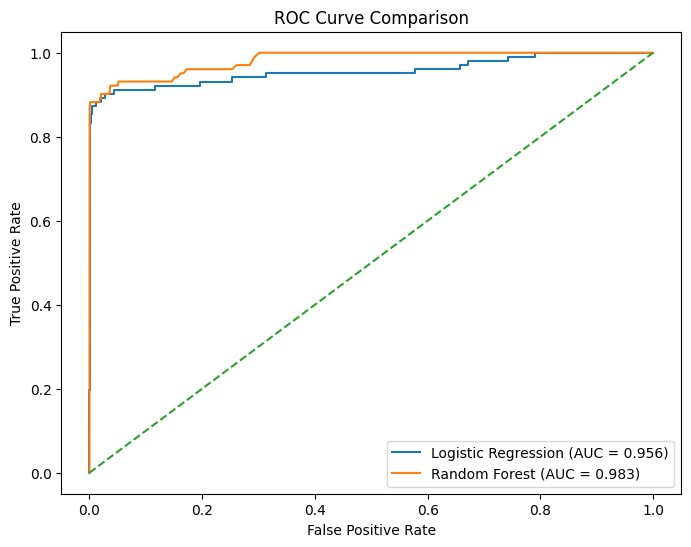

In [104]:
# Logistic Regression
y_proba_lr = model.predict_proba(X_valid)[:, 1]
fpr_lr, tpr_lr, _ = roc_curve(y_valid, y_proba_lr)
roc_auc_lr = auc(fpr_lr, tpr_lr)

# Random Forest
y_proba_rf = rf_model.predict_proba(X_valid)[:, 1]
fpr_rf, tpr_rf, _ = roc_curve(y_valid, y_proba_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {roc_auc_lr:.3f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {roc_auc_rf:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend(loc="lower right")
plt.show()

## Conclusiones

Este proyecto demuestra cómo aplicar técnicas de machine learning para la detección de fraude en datasets altamente desbalanceados.

**Las principales conclusiones son:**

* El manejo adecuado del desbalance de clases es fundamental para obtener modelos útiles.
* El ajuste del threshold de clasificación puede mejorar significativamente el desempeño del modelo.
* Los modelos basados en árboles como Random Forest pueden capturar relaciones no lineales que modelos lineales no detectan.
* Métricas como Precision-Recall AUC son especialmente relevantes en problemas de fraude.

El modelo desarrollado muestra resultados prometedores y podría servir como base para sistemas de detección de fraude más avanzados.

### Trabajo Futuro

Posibles mejoras incluyen:

* Implementar modelos más avanzados como XGBoost o LightGBM
* Aplicar técnicas de SMOTE o Hybrid Sampling
* Optimizar hiperparámetros mediante Grid Search o Random Search
* Analizar feature importance y explicabilidad del modelo
* Implementar un pipeline de producción para detección en tiempo real